## Figure A7 (PCA Embeddings) - Tahoe DEG Boxplot

PCA embeddings from tahoe_PCA_emb.pkl, split by dosage.
Three plots: dose 3.33333 uM (CVCL_0320), dose 10 uM (CVCL_0023), and aggregate across both.

In [1]:
import pandas as pd
import seaborn as sns
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

In [2]:
results_path = "/home/matthew-mella/valinor/foundation-models-perturbation/results/"

with open(results_path + "metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

model_type_palette = fig_index['drugs_model_type_palette']
hue_order = fig_index['drugs_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])
mpl.rcParams.update({"legend.loc": "upper right"})

In [3]:
# Method map for PCA embedding DEG models + additional embeddings
method_map = {
    "prior": ["Train Mean", "Negative Control"],
    "no_change": ["No Change", "Negative Control"],
    "random": ["Random Embeddings", "Negative Control"],
    "pca": ["Idealized Baseline", "Positive Control"],
    "PCA.logFC_v1_64": ["PCA.logFC v1 (64)", "Molecule Structure"],
    "PCA.t_v1_64": ["PCA.t v1 (64)", "Molecule Structure"],
    "PCA.logFC_v2_64": ["PCA.logFC v2 (64)", "Molecule Structure"],
    "PCA.t_v2_64": ["PCA.t v2 (64)", "Molecule Structure"],
    "PCA.logFC_v2_128": ["PCA.logFC v2 (128)", "Molecule Structure"],
    "PCA.t_v2_128": ["PCA.t v2 (128)", "Molecule Structure"],
    "PCA.logFC_v3_64": ["PCA.logFC v3 (64)", "Molecule Structure"],
    "PCA.t_v3_64": ["PCA.t v3 (64)", "Molecule Structure"],
    "PCA.logFC_v3_128": ["PCA.logFC v3 (128)", "Molecule Structure"],
    "PCA.t_v3_128": ["PCA.t v3 (128)", "Molecule Structure"],
    "PCA.logFC_v4_64": ["PCA.logFC v4 (64)", "Molecule Structure"],
    "PCA.t_v4_64": ["PCA.t v4 (64)", "Molecule Structure"],
    "PCA.logFC_v4_128": ["PCA.logFC v4 (128)", "Molecule Structure"],
    "PCA.t_v4_128": ["PCA.t v4 (128)", "Molecule Structure"],
    "MiniMol": ["MiniMol", "SMILES Transformer"],
    "AIDOcell_100M_Norman_Aligned_(D=640)_concat": ["AIDO.Cell 100M - Norman", "Gene Target"],
    "chatgpt": ["ChatGPT", "LLM"],
    "ECFP:2_pkl": ["ECFP:2", "Molecule Structure"],
}

print(f"Models in method_map: {len(method_map)}")

Models in method_map: 22


In [4]:
def plot_deg_boxplot(df, method_map, title, save_path):
    score = "f1_score"

    fig, ax = plt.subplots(figsize=(15, 11), constrained_layout=True)

    df_subset = df[df["name"].isin(method_map)].copy()
    print(f"Rows after filtering to known models: {len(df_subset)}")

    df_subset["fold"] = df_subset["fold"].apply(
        lambda x: x if "." not in str(x) else x.split(".")[1]
    )
    df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
    df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

    # Aggregate: mean f1 across cell lines, per fold
    df_subset = df_subset.groupby(["fold", "name", "Model type"])[score].mean().reset_index()

    present_hues = [
        h for h in hue_order
        if h in df_subset["Model type"].unique()
    ]

    name_order = [name for name, _ in method_map.values() if name in df_subset["name"].values]

    g = sns.boxplot(
        data=df_subset,
        y="name",
        order=name_order,
        hue="Model type",
        hue_order=present_hues,
        x=score,
        ax=ax,
        whis=(0, 100),
        width=0.75,
        palette=model_type_palette,
    )

    sns.stripplot(
        data=df_subset,
        y="name",
        order=name_order,
        color="black",
        alpha=0.5,
        s=5,
        x=score,
        ax=ax,
    )

    g.grid(axis="y")
    g.set(ylabel=None, title=title)
    g.set_xlabel('Macro F1')
    g.legend(title=None)

    # Best model (excluding controls)
    best_mask = (
        (df_subset["Model type"] != "Positive Control") &
        (df_subset["Model type"] != "Negative Control")
    )
    best_group = df_subset.loc[best_mask].groupby("name")[score].median()
    if len(best_group) > 0:
        best_name = best_group.idxmax()
        best_level = best_group.loc[best_name]
        best_model_type = df_subset.loc[df_subset["name"] == best_name, "Model type"].iloc[0]
        g.axvline(best_level, color=model_type_palette[best_model_type],
                  linestyle="--", linewidth=1, zorder=99, alpha=0.75)
        print(f"Best non-control model: {best_name} (median F1={best_level:.4f})")

    # Train Mean line
    train_mean_data = df_subset[df_subset["name"] == "Train Mean"][score]
    if len(train_mean_data) > 0:
        g.axvline(train_mean_data.median(), color=model_type_palette["Negative Control"],
                  linestyle="--", linewidth=1, zorder=99, alpha=0.75)

    # Idealized Baseline line
    pca_data = df_subset[df_subset["name"] == "Idealized Baseline"][score]
    if len(pca_data) > 0:
        g.axvline(pca_data.median(), color=model_type_palette["Positive Control"],
                  linestyle="--", linewidth=1, zorder=-99, alpha=0.75)

    plt.savefig(save_path)
    plt.show()
    print(f"Saved to {save_path}")

## Dose 3.33333 uM (CVCL_0320)

In [5]:
df_dose3 = pd.read_csv(results_path + "scores/tahoe_deg_pca_emb_dose3.csv", index_col=0)
print(f"Loaded {len(df_dose3)} rows, {df_dose3['name'].nunique()} unique models")
df_dose3.head()

Loaded 115 rows, 23 unique models


,dataset,fold,metrics,name,roc_auc,average_precision,f1_score,recall,precision,f1_classwise,f1_score_nans_are_zeros,primary_metric,cell_line,quantile
0,expression/pert_prediction_tahoe_deg,CVCL_0320.0,"{'roc_auc': 0.2328166961669922, 'average_preci...",prior,0.232817,0.674500,0.651727,0.674500,0.636547,NaN,NaN,f1_score,CVCL_0320,NaN
1,expression/pert_prediction_tahoe_deg,CVCL_0320.0,"{'roc_auc': 0.2328166961669922, 'average_preci...",most_frequent,0.232817,0.674500,0.651727,0.674500,0.636547,NaN,NaN,f1_score,CVCL_0320,NaN
2,expression/pert_prediction_tahoe_deg,CVCL_0320.0,"{'roc_auc': 0.2328166961669922, 'average_preci...",no_change,0.232817,0.674500,0.651580,0.674500,0.636407,NaN,NaN,f1_score,CVCL_0320,NaN
3,expression/pert_prediction_tahoe_deg,CVCL_0320.1,"{'roc_auc': 0.2307853251695633, 'average_preci...",no_change,0.230785,0.674424,0.645936,0.674424,0.627659,NaN,NaN,f1_score,CVCL_0320,NaN
4,expression/pert_prediction_tahoe_deg,CVCL_0320.1,"{'roc_auc': 0.2307853251695633, 'average_preci...",prior,0.230785,0.674424,0.646460,0.674424,0.628217,NaN,NaN,f1_score,CVCL_0320,NaN


Rows after filtering to known models: 110
Best non-control model: MiniMol (median F1=0.6593)


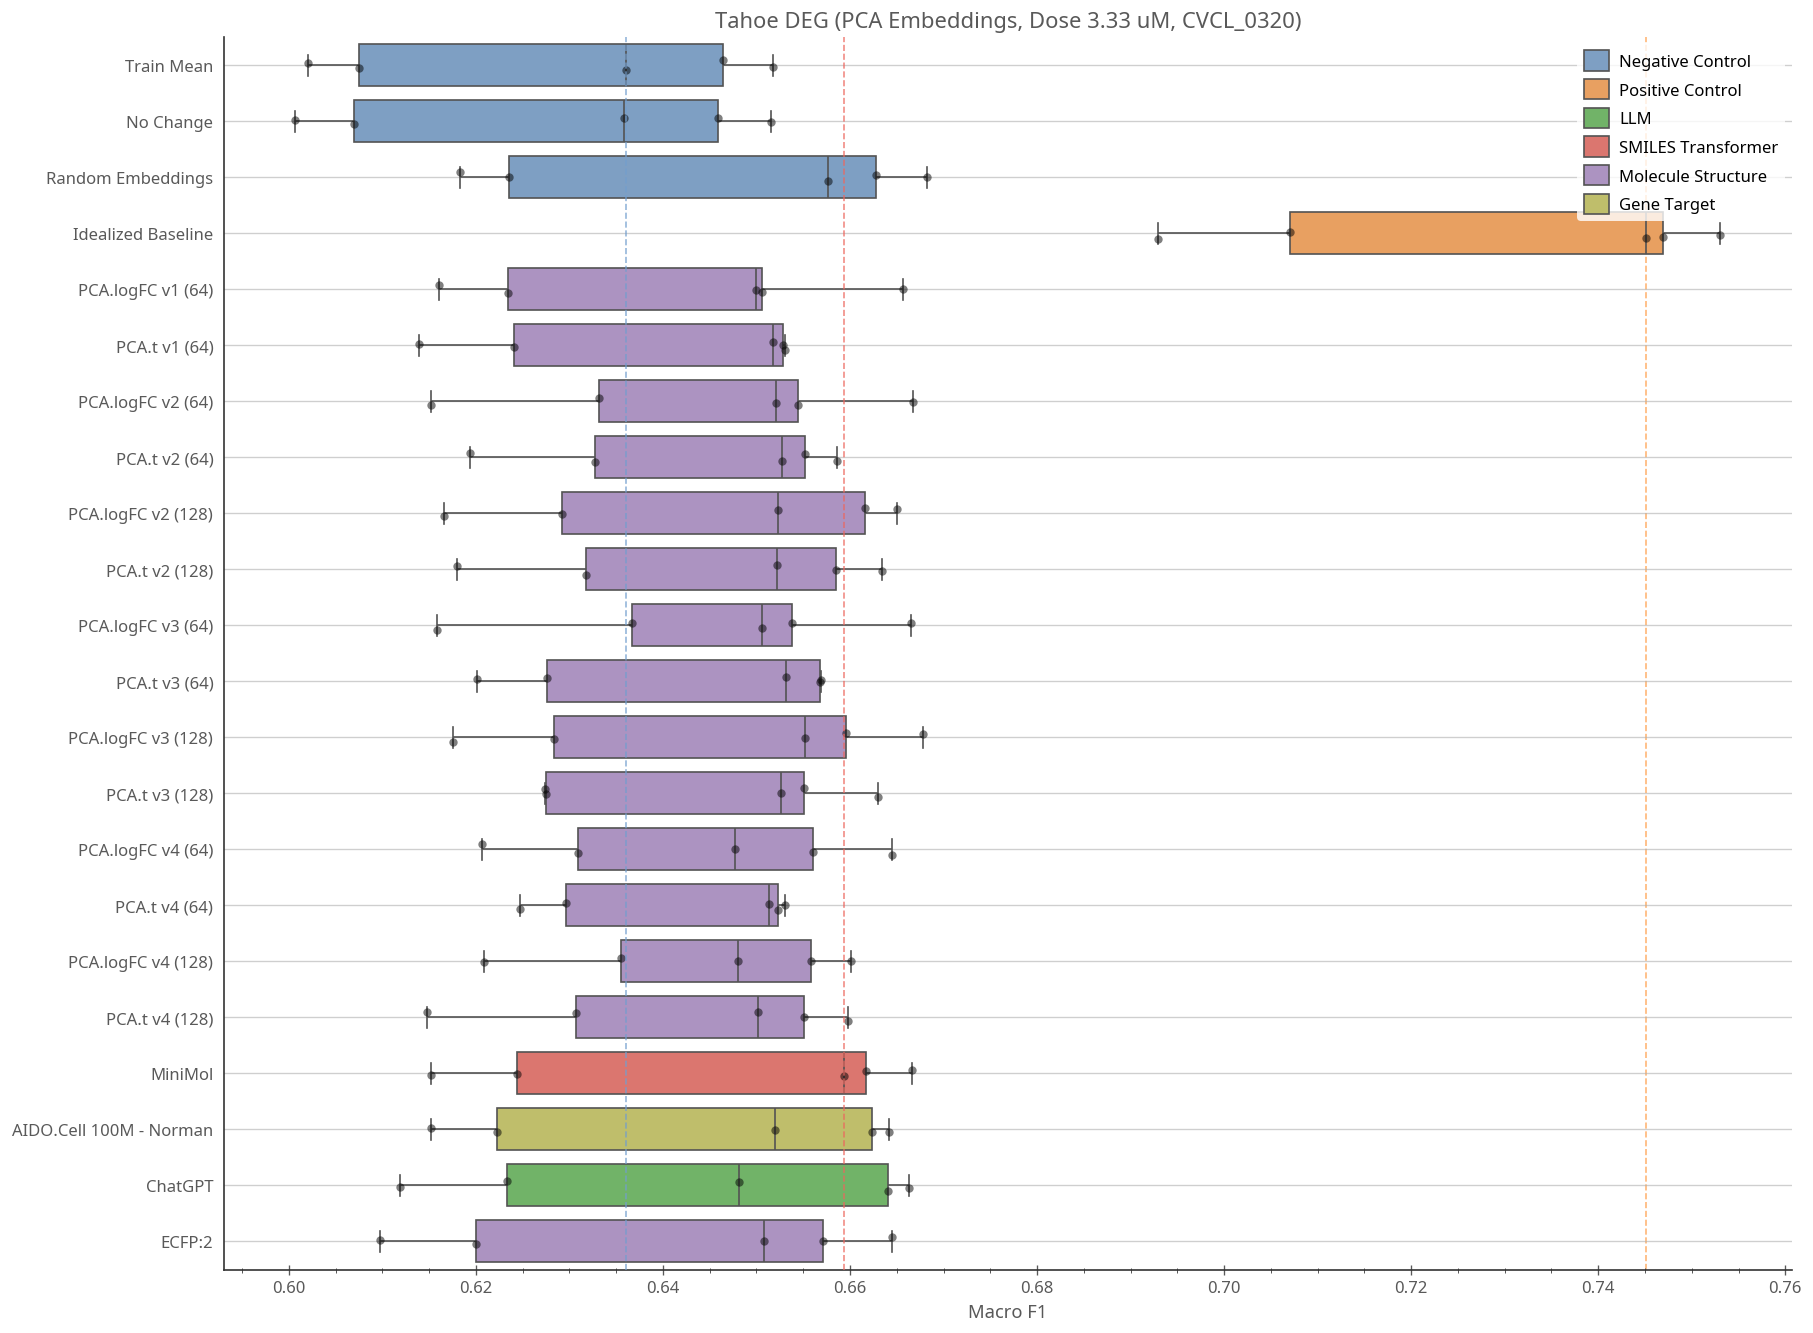

Saved to fig_A7_pca_emb_dose3.pdf


In [6]:
plot_deg_boxplot(
    df_dose3, method_map,
    title="Tahoe DEG (PCA Embeddings, Dose 3.33 uM, CVCL_0320)",
    save_path="fig_A7_pca_emb_dose3.pdf",
)

## Dose 10 uM (CVCL_0023)

In [7]:
df_dose10 = pd.read_csv(results_path + "scores/tahoe_deg_pca_emb_dose10.csv", index_col=0)
print(f"Loaded {len(df_dose10)} rows, {df_dose10['name'].nunique()} unique models")
df_dose10.head()

Loaded 115 rows, 23 unique models


,dataset,fold,metrics,name,roc_auc,average_precision,f1_score,recall,precision,f1_classwise,f1_score_nans_are_zeros,primary_metric,cell_line,quantile
0,expression/pert_prediction_tahoe_deg,CVCL_0023.0,"{'roc_auc': 0.18203172087669373, 'average_prec...",no_change,0.182032,0.743818,0.723697,0.743793,0.710051,NaN,NaN,f1_score,CVCL_0023,NaN
1,expression/pert_prediction_tahoe_deg,CVCL_0023.0,"{'roc_auc': 0.18203172087669373, 'average_prec...",prior,0.182032,0.743818,0.721125,0.743793,0.707429,NaN,NaN,f1_score,CVCL_0023,NaN
2,expression/pert_prediction_tahoe_deg,CVCL_0023.0,"{'roc_auc': 0.18203172087669373, 'average_prec...",most_frequent,0.182032,0.743818,0.721125,0.743793,0.707429,NaN,NaN,f1_score,CVCL_0023,NaN
3,expression/pert_prediction_tahoe_deg,CVCL_0023.1,"{'roc_auc': 0.2048202008008957, 'average_preci...",prior,0.204820,0.710262,0.677646,0.710262,0.658189,NaN,NaN,f1_score,CVCL_0023,NaN
4,expression/pert_prediction_tahoe_deg,CVCL_0023.1,"{'roc_auc': 0.2048202008008957, 'average_preci...",no_change,0.204820,0.710262,0.676624,0.710087,0.657256,NaN,NaN,f1_score,CVCL_0023,NaN


Rows after filtering to known models: 110
Best non-control model: AIDO.Cell 100M - Norman (median F1=0.7081)


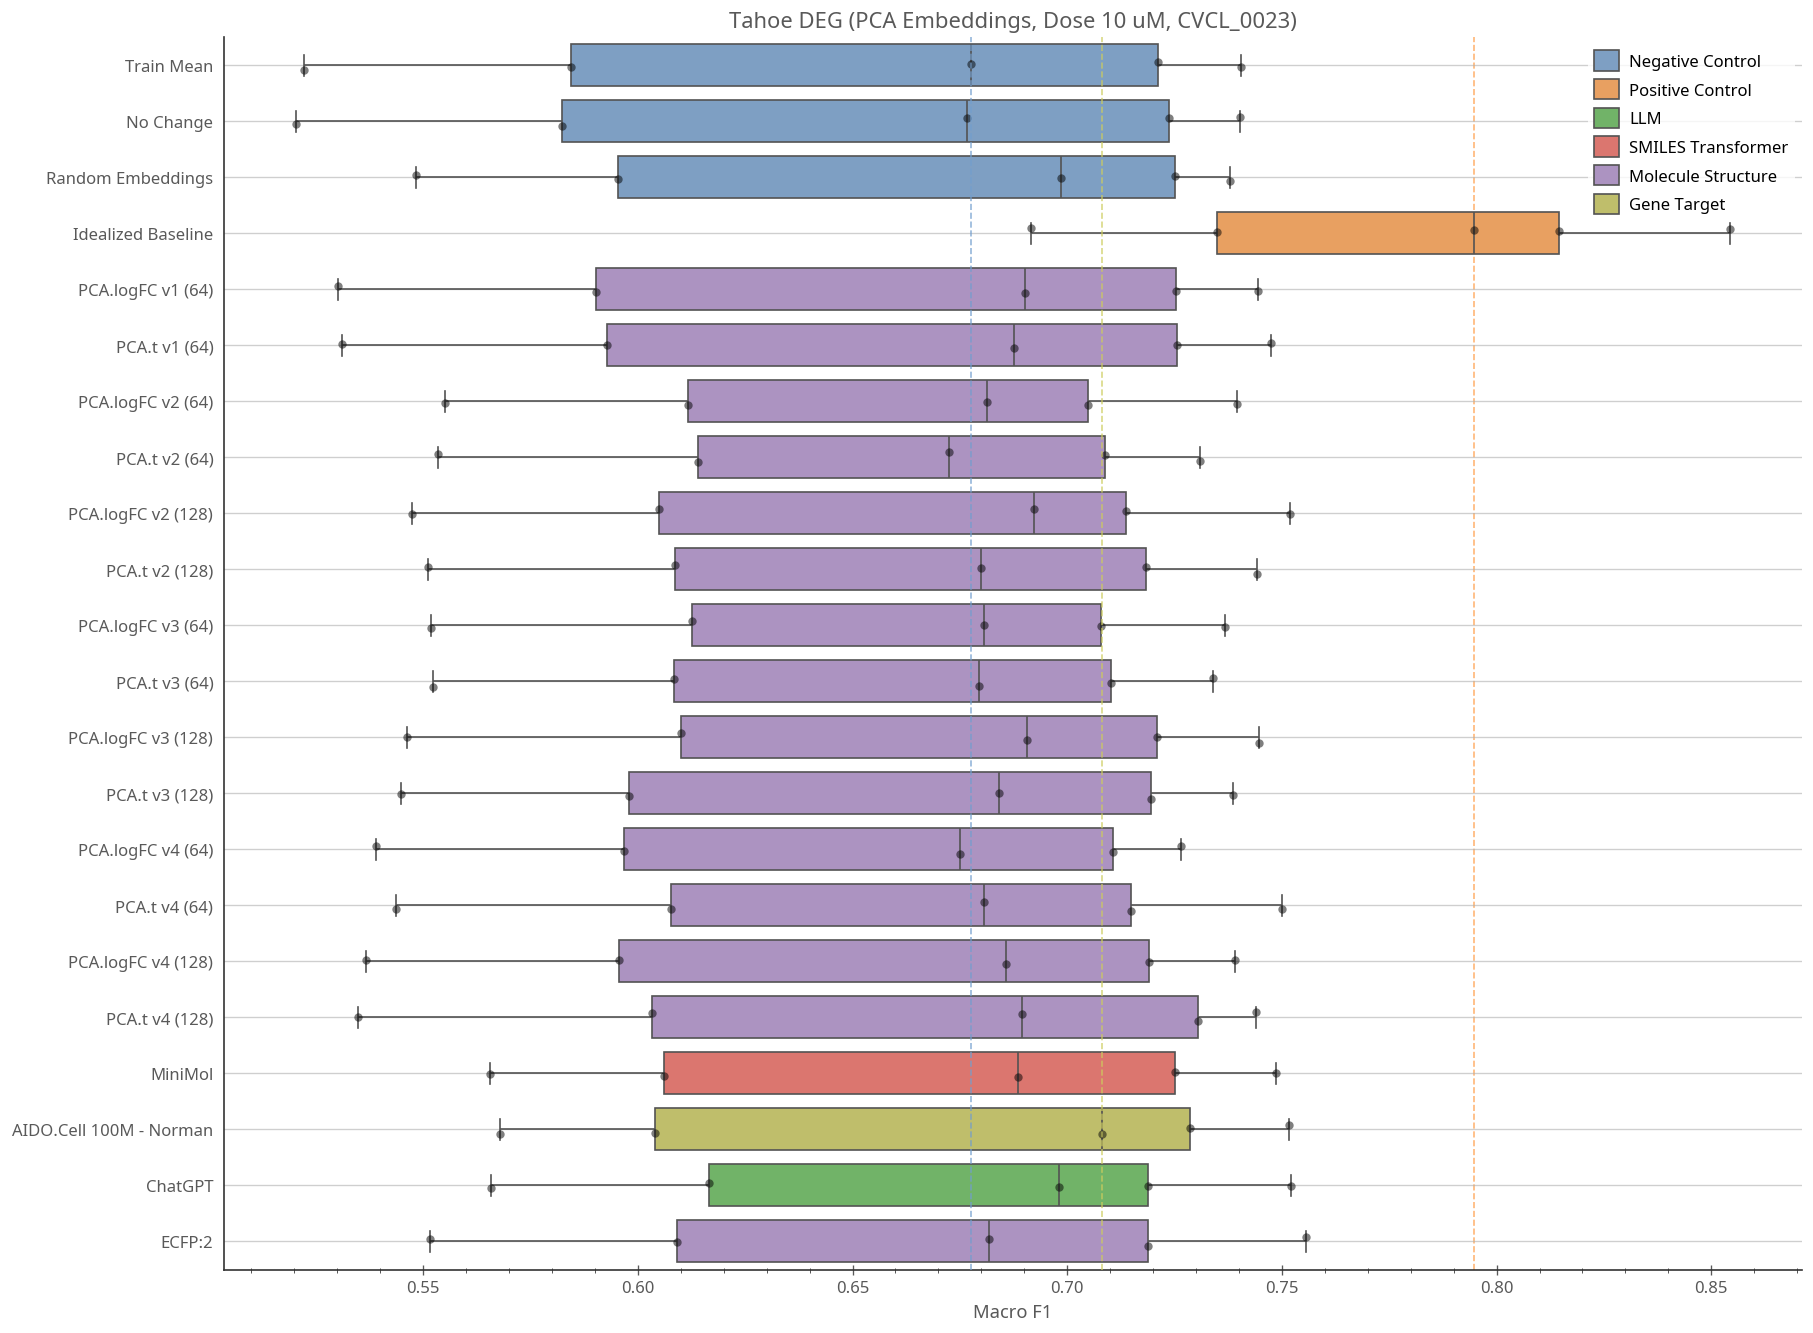

Saved to fig_A7_pca_emb_dose10.pdf


In [8]:
plot_deg_boxplot(
    df_dose10, method_map,
    title="Tahoe DEG (PCA Embeddings, Dose 10 uM, CVCL_0023)",
    save_path="fig_A7_pca_emb_dose10.pdf",
)

## Aggregate (both doses / cell lines)

In [9]:
df_agg = pd.concat([df_dose3, df_dose10], ignore_index=True)
print(f"Aggregate: {len(df_agg)} rows, {df_agg['name'].nunique()} unique models, {df_agg['cell_line'].nunique()} cell lines")
df_agg.head()

Aggregate: 230 rows, 23 unique models, 2 cell lines


,dataset,fold,metrics,name,roc_auc,average_precision,f1_score,recall,precision,f1_classwise,f1_score_nans_are_zeros,primary_metric,cell_line,quantile
0,expression/pert_prediction_tahoe_deg,CVCL_0320.0,"{'roc_auc': 0.2328166961669922, 'average_preci...",prior,0.232817,0.674500,0.651727,0.674500,0.636547,NaN,NaN,f1_score,CVCL_0320,NaN
1,expression/pert_prediction_tahoe_deg,CVCL_0320.0,"{'roc_auc': 0.2328166961669922, 'average_preci...",most_frequent,0.232817,0.674500,0.651727,0.674500,0.636547,NaN,NaN,f1_score,CVCL_0320,NaN
2,expression/pert_prediction_tahoe_deg,CVCL_0320.0,"{'roc_auc': 0.2328166961669922, 'average_preci...",no_change,0.232817,0.674500,0.651580,0.674500,0.636407,NaN,NaN,f1_score,CVCL_0320,NaN
3,expression/pert_prediction_tahoe_deg,CVCL_0320.1,"{'roc_auc': 0.2307853251695633, 'average_preci...",no_change,0.230785,0.674424,0.645936,0.674424,0.627659,NaN,NaN,f1_score,CVCL_0320,NaN
4,expression/pert_prediction_tahoe_deg,CVCL_0320.1,"{'roc_auc': 0.2307853251695633, 'average_preci...",prior,0.230785,0.674424,0.646460,0.674424,0.628217,NaN,NaN,f1_score,CVCL_0320,NaN


Rows after filtering to known models: 220
Best non-control model: AIDO.Cell 100M - Norman (median F1=0.6834)


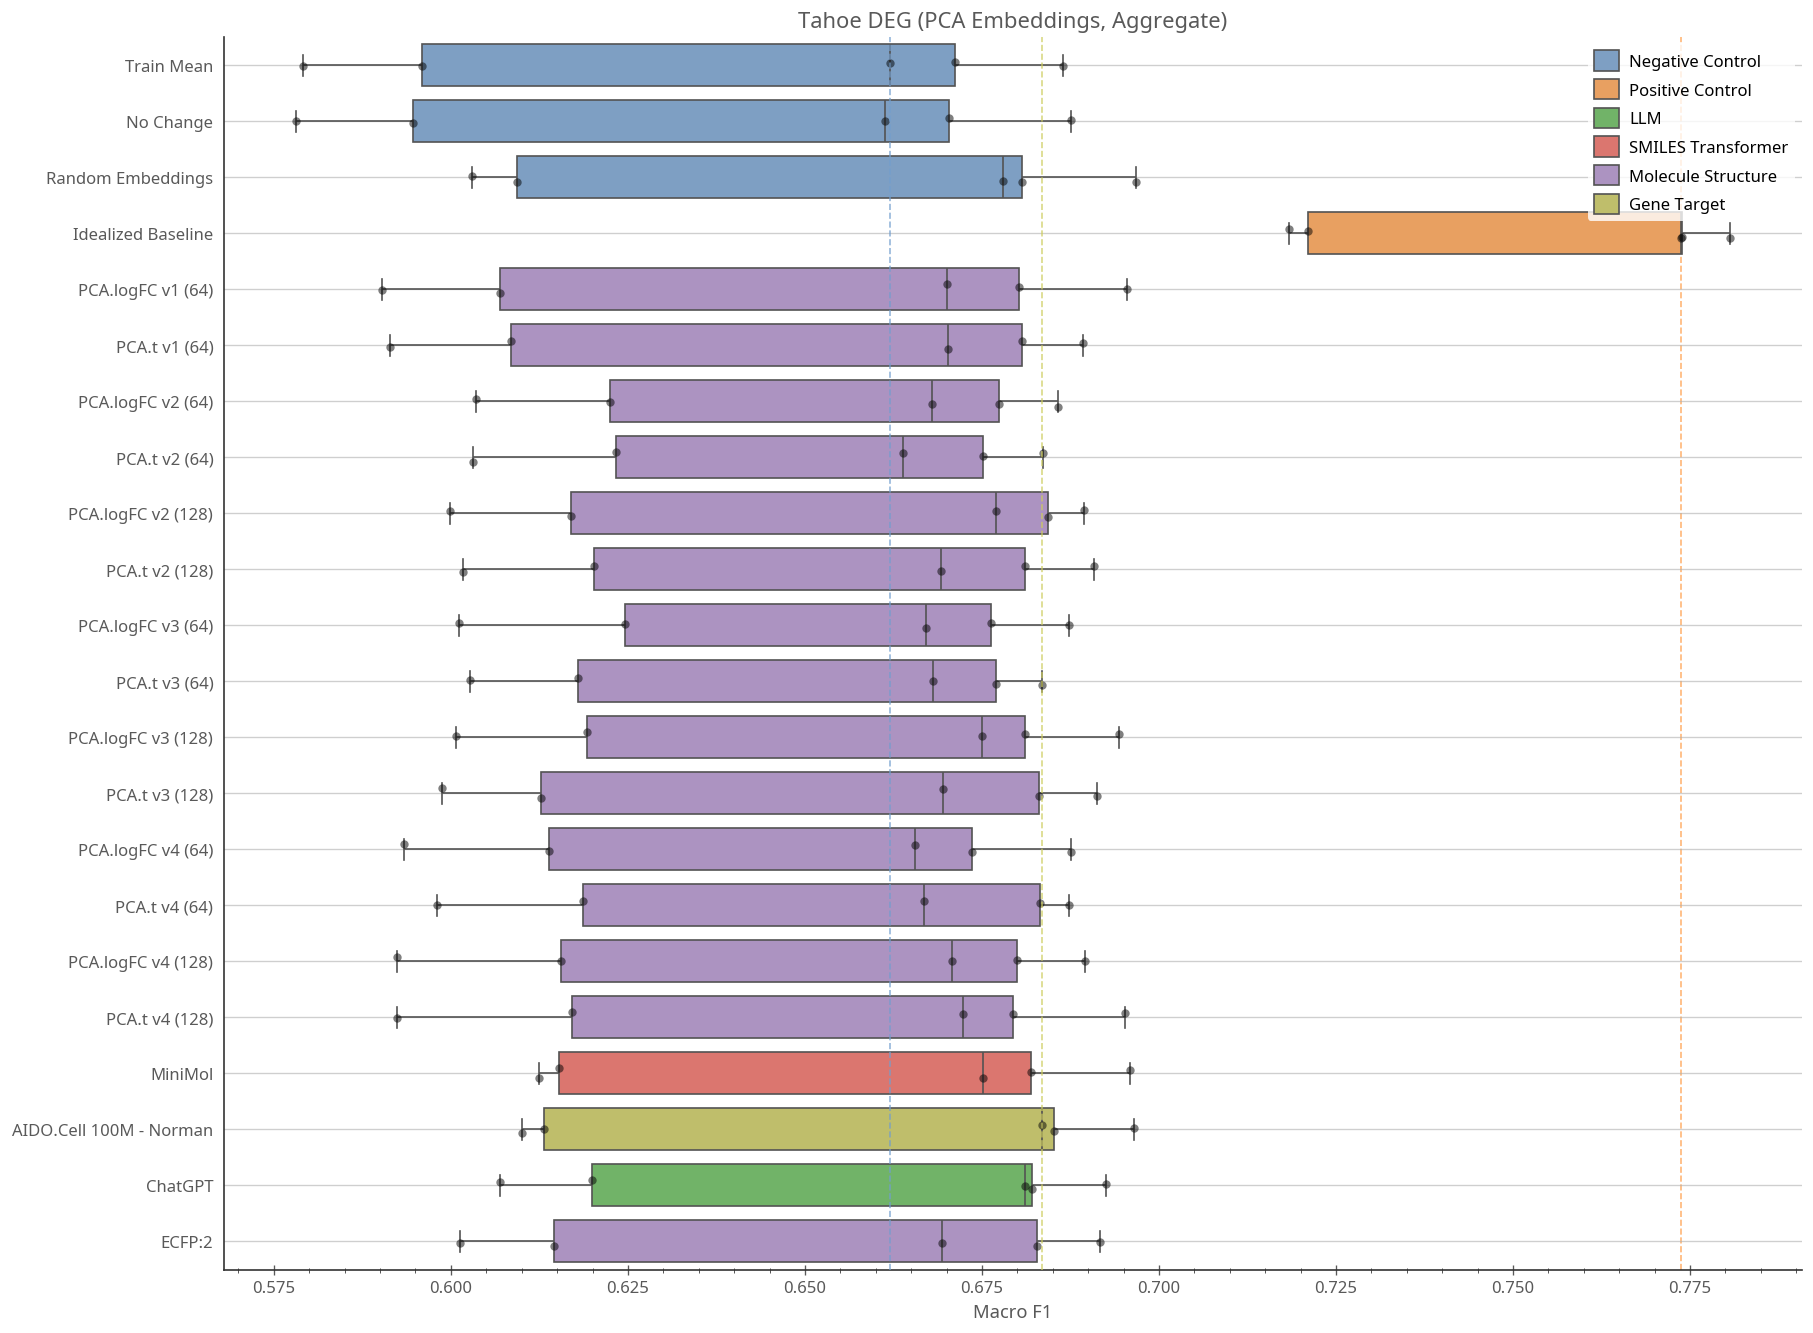

Saved to fig_A7_pca_emb_aggregate.pdf


In [10]:
plot_deg_boxplot(
    df_agg, method_map,
    title="Tahoe DEG (PCA Embeddings, Aggregate)",
    save_path="fig_A7_pca_emb_aggregate.pdf",
)